In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(
    lambda x: x if x != "developer_written" else "source"
)

print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())


Original rows: 6140
After removing obfuscated: 5612

Verdict value counts:
verdict
0    2898
1    2714
Name: count, dtype: int64

Code location value counts:
code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64


In [3]:
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
print("\napk_size_scaled summary:")
print(df["apk_size_scaled"].describe())



apk_size_scaled summary:
count    5612.000000
mean        0.489310
std         1.437216
min        -0.719854
25%        -0.336389
50%         0.000000
75%         0.663611
max         9.086488
Name: apk_size_scaled, dtype: float64


In [4]:
category_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
ord_map = {c: i for i, c in enumerate(category_order)}

df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

print("\nApp popularity encoded value counts:")
print(df["app_popularity_encoded"].value_counts().sort_index())




App popularity encoded value counts:
app_popularity_encoded
0     626
1     604
2     317
3     323
4     415
5     449
6     413
7     704
8     602
9     641
10    518
Name: count, dtype: int64


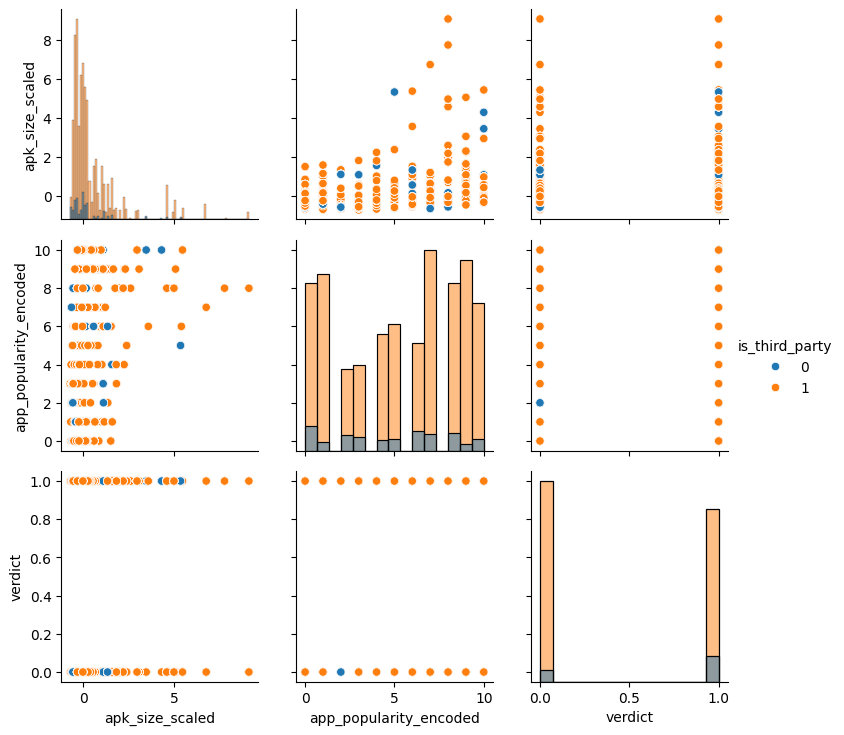

In [5]:
cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

In [6]:
n_bootstraps = 200
boot_means = {
    "apk_size_scaled": [],
    "verdict": [],
    "is_third_party": [],
}

for _ in range(n_bootstraps):
    boot_sample = df.sample(frac=1, replace=True)
    boot_means["apk_size_scaled"].append(boot_sample["apk_size_scaled"].mean())
    boot_means["verdict"].append(boot_sample["verdict"].mean())
    boot_means["is_third_party"].append(boot_sample["is_third_party"].mean())

summary = {}
for col, values in boot_means.items():
    values = np.array(values)
    summary[col] = {
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "95% CI lower": np.percentile(values, 2.5),
        "95% CI upper": np.percentile(values, 97.5),
    }

summary_df = pd.DataFrame(summary).T
print("\nBootstrap summary (descriptive stats):")
print(summary_df)




Bootstrap summary (descriptive stats):
                     mean       std  95% CI lower  95% CI upper
apk_size_scaled  0.488719  0.018444      0.453652      0.522712
verdict          0.484184  0.006515      0.472015      0.495915
is_third_party   0.908983  0.003792      0.901818      0.916091


In [7]:
df["is_third_party"].value_counts()

is_third_party
1    5101
0     511
Name: count, dtype: int64

In [8]:
# tp_dev = df.loc[df["is_third_party"] == 0, "verdict"].mean()
# tp_third = df.loc[df["is_third_party"] == 1, "verdict"].mean()
# n_dev = (df["is_third_party"] == 0).sum()
# n_third = (df["is_third_party"] == 1).sum()

# print("Dev TP rate:", tp_dev, "n =", n_dev)
# print("Third-party TP rate:", tp_third, "n =", n_third)
# print("Observed difference:", tp_third - tp_dev)


In [9]:
# from statsmodels.stats.power import NormalIndPower
# from statsmodels.stats.proportion import proportion_effectsize

# alpha = 0.05
# power_target = 0.8

# effect_size = proportion_effectsize(tp_third, tp_dev)  
# ratio = n_third / n_dev  

# power_analysis = NormalIndPower()

# power = power_analysis.power(
#     effect_size=effect_size,
#     nobs1=n_dev,
#     alpha=alpha,
#     ratio=ratio,
#     alternative='two-sided'
# )
# print("Post-hoc power for RQ1 with current N:", power)

# n_dev_required = power_analysis.solve_power(
#     effect_size=effect_size,
#     power=power_target,
#     alpha=alpha,
#     ratio=ratio,
#     alternative='two-sided'
# )
# n_third_required = n_dev_required * ratio

# print("Required n_dev for 80% power:", n_dev_required)
# print("Required n_third for 80% power:", n_third_required)


In [10]:
majority = df[df["is_third_party"] == 1]
minority = df[df["is_third_party"] == 0]
n_min = len(minority)
down_sample = majority.sample(n=n_min, replace=False, random_state=42)

df = pd.concat([down_sample, minority], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["is_third_party"].value_counts())

is_third_party
0    511
1    511
Name: count, dtype: int64


In [11]:
# tp_dev = df.loc[df["is_third_party"] == 0, "verdict"].mean()
# tp_third = df.loc[df["is_third_party"] == 1, "verdict"].mean()
# n_dev = (df["is_third_party"] == 0).sum()
# n_third = (df["is_third_party"] == 1).sum()

# print("Dev TP rate:", tp_dev, "n =", n_dev)
# print("Third-party TP rate:", tp_third, "n =", n_third)
# print("Observed difference:", tp_third - tp_dev)


In [12]:

# alpha = 0.05
# power_target = 0.8

# effect_size = proportion_effectsize(tp_third, tp_dev)  
# ratio = n_third / n_dev  

# power_analysis = NormalIndPower()

# power = power_analysis.power(
#     effect_size=effect_size,
#     nobs1=n_dev,
#     alpha=alpha,
#     ratio=ratio,
#     alternative='two-sided'
# )
# print("Post-hoc power for RQ1 with current N:", power)

# n_dev_required = power_analysis.solve_power(
#     effect_size=effect_size,
#     power=power_target,
#     alpha=alpha,
#     ratio=ratio,
#     alternative='two-sided'
# )
# n_third_required = n_dev_required * ratio

# print("Required n_dev for 80% power:", n_dev_required)
# print("Required n_third for 80% power:", n_third_required)


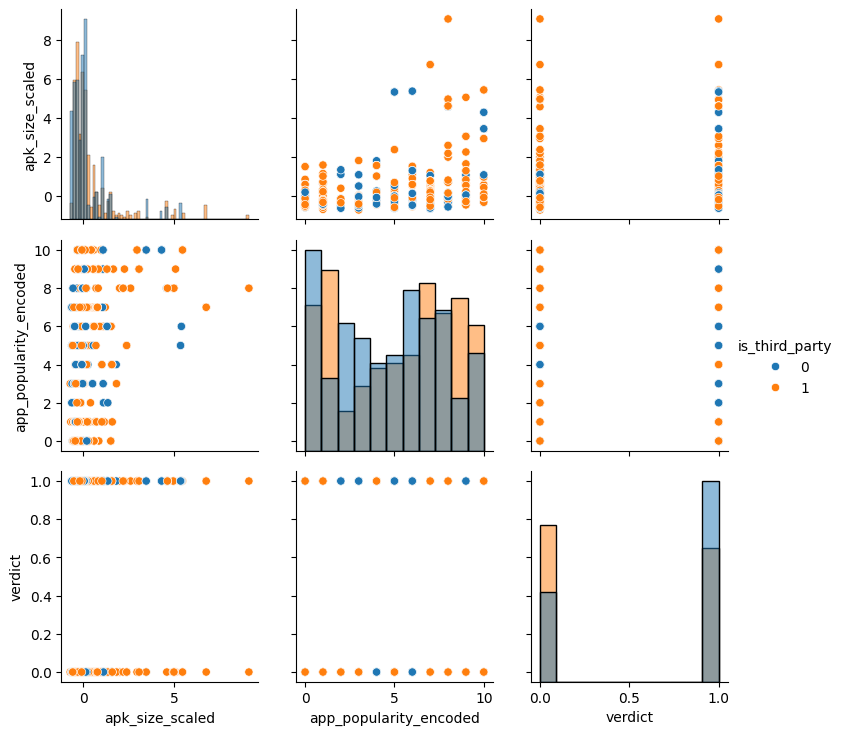

In [13]:
cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

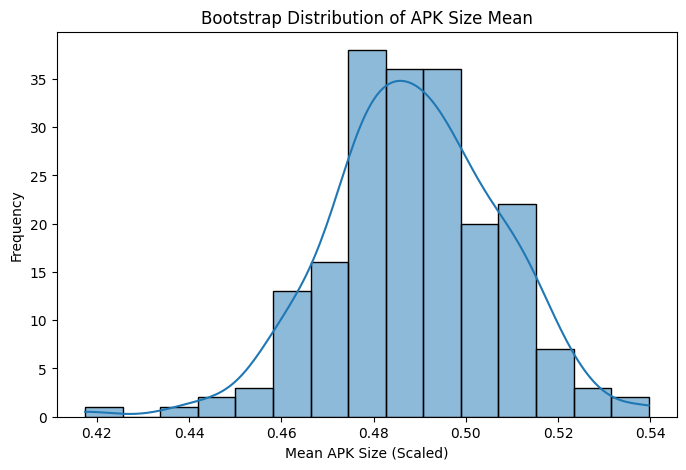

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(boot_means["apk_size_scaled"], kde=True)
plt.title("Bootstrap Distribution of APK Size Mean")
plt.xlabel("Mean APK Size (Scaled)")
plt.ylabel("Frequency")
plt.show()

In [15]:
causal_graph = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> is_third_party;
    app_popularity_encoded -> verdict;
}
"""

causal_graph_2 = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> is_third_party;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
}
"""

causal_graph_only_size = """
digraph {
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    is_third_party -> verdict;
}
"""

causal_graph_only_app_popularity = """
digraph {
    is_third_party -> verdict;
    app_popularity_encoded -> is_third_party;
    app_popularity_encoded -> verdict;
}
"""

causal_graph_after_correlation_test = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    app_popularity_encoded -> is_third_party;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
}
"""


In [16]:
model = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph.replace("\n", " "),
    common_causes=["apk_size_scaled", "app_popularity_encoded"],
)

model_2 = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_2.replace("\n", " "),
    common_causes=["apk_size_scaled", "app_popularity_encoded"],
)

model_only_size = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_size.replace("\n", " "),
    common_causes=["apk_size_scaled"],
)

model_only_app_popularity = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_app_popularity.replace("\n", " "),
    common_causes=["app_popularity_encoded"],
)

model_after_correlation_test = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_after_correlation_test.replace("\n", " "),
    common_causes=["app_popularity_encoded"],
)


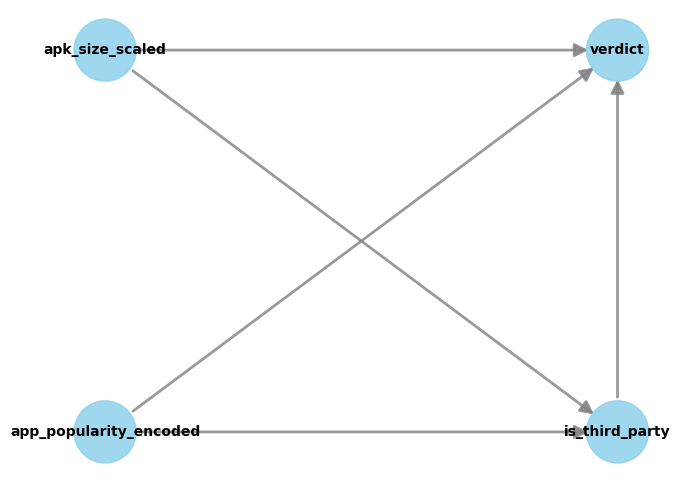

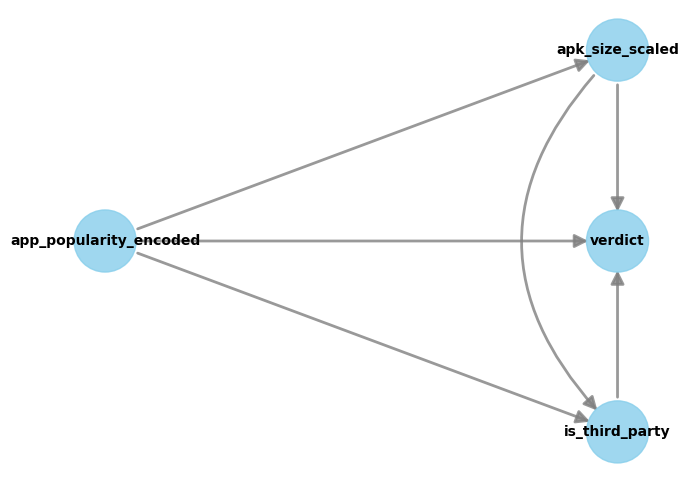

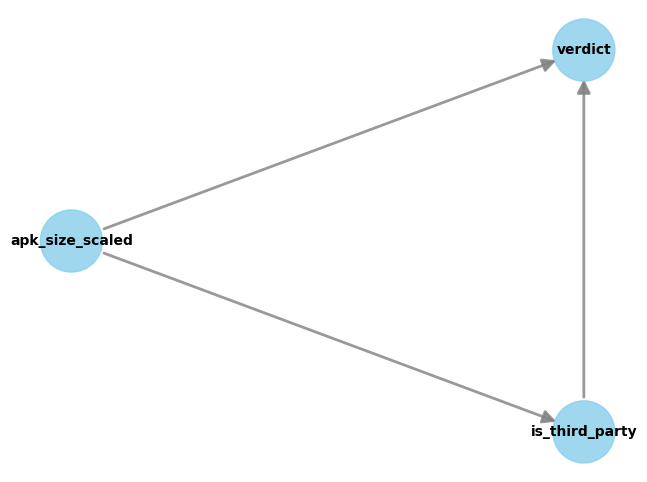

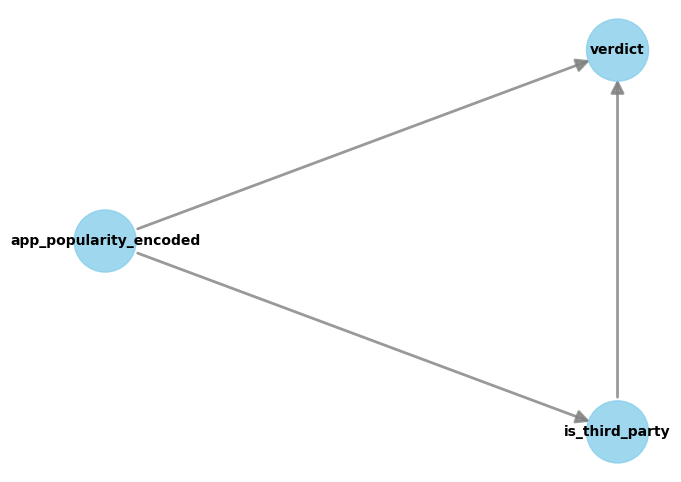

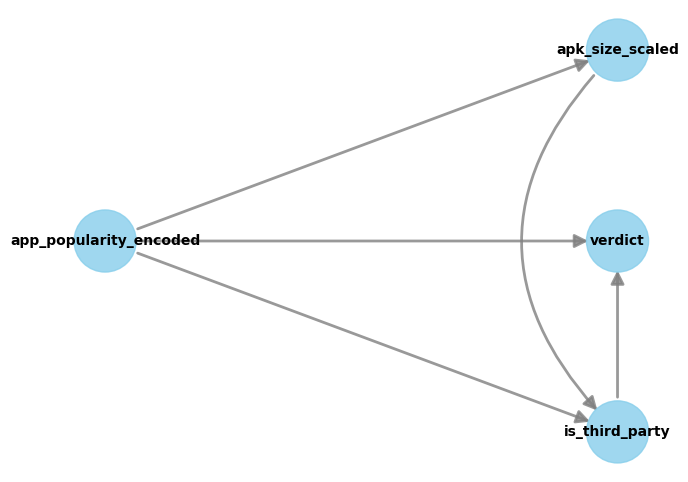

In [17]:
model.view_model()
model_2.view_model()
model_only_size.view_model()
model_only_app_popularity.view_model()
model_after_correlation_test.view_model()


In [18]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_2 = model_2.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_size = model_only_size.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_app_popularity = model_only_app_popularity.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_after_correlation_test = model_after_correlation_test.identify_effect(
    proceed_when_unidentifiable=True
)

print("\n=== Identified estimands ===")
print(identified_estimand, "\n", "------" * 10)
print(identified_estimand_2, "\n", "------" * 10)
print(identified_estimand_only_size, "\n", "------" * 10)
print(identified_estimand_only_app_popularity, "\n", "------" * 10)
print(identified_estimand_after_correlation_test)



=== Identified estimands ===
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                           
─────────────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[is_third_party]                                                   
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,app_popularity_encoded,apk_size_scaled,U) = P(verdict|is_third_party,app_popularity_encoded,apk_size_scaled)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                                           
─────────────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[is_third_party]                                                   
Estimand assumption 1, Un

In [19]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True,
)

estimate_2 = model_2.estimate_effect(
    identified_estimand_2,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True,
)

estimate_only_size = model_only_size.estimate_effect(
    identified_estimand_only_size,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True,
)

estimate_only_app_popularity = model_only_app_popularity.estimate_effect(
    identified_estimand_only_app_popularity,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True,
)

estimate_after_correlation_test = model_after_correlation_test.estimate_effect(
    identified_estimand_after_correlation_test,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True,
)

print("\n=== Causal effect estimates ===")
print(estimate, "\n", "-------" * 10)
print(estimate_2, "\n", "-------" * 10)
print(estimate_only_size, "\n", "-------" * 10)
print(estimate_only_app_popularity, "\n", "-------" * 10)
print(estimate_after_correlation_test)


=== Causal effect estimates ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                           
─────────────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[is_third_party]                                                   
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,app_popularity_encoded,apk_size_scaled,U) = P(verdict|is_third_party,app_popularity_encoded,apk_size_scaled)

## Realized estimand
b: verdict~is_third_party+app_popularity_encoded+apk_size_scaled
Target units: ate

## Estimate
Mean value: -0.32974559686888455
95.0% confidence interval: (np.float64(-0.46868884540117417), np.float64(-0.28375733855185914))
 
 ----------------------------------------------------------------------
*** Causal Estimate ***

## Identified estimand
Estimand type: Est

In [20]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 1)", "----" * 15)
for method in refutation_methods:
    ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
    print(f"\nRefuter: {method}\n", ref)

print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 2)", "----" * 15)
for method in refutation_methods:
    ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)
    print(f"\nRefuter: {method}\n", ref)

print("\n", "----" * 15, "Only size as confounder", "----" * 15)
for method in refutation_methods:
    ref = model_only_size.refute_estimate(identified_estimand_only_size, estimate_only_size, method_name=method)
    print(f"\nRefuter: {method}\n", ref)

print("\n", "----" * 15, "Only app_popularity as confounder", "----" * 15)
for method in refutation_methods:
    ref = model_only_app_popularity.refute_estimate(
        identified_estimand_only_app_popularity, estimate_only_app_popularity, method_name=method
    )
    print(f"\nRefuter: {method}\n", ref)

print("\n", "----" * 15, "Refutation after correlation test graph", "----" * 15)
for method in refutation_methods:
    ref = model_after_correlation_test.refute_estimate(
        identified_estimand_after_correlation_test, estimate_after_correlation_test, method_name=method
    )
    print(f"\nRefuter: {method}\n", ref)



 ------------------------------------------------------------ Both size and app_popularity as confounders (graph 1) ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.32974559686888455
New effect:-0.3297455968688845
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.32974559686888455
New effect:-0.0002446183953033268
p value:0.94


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.32974559686888455
New effect:-0.3136552567237164
p value:0.6799999999999999


 ------------------------------------------------------------ Both size and app_popularity as confounders (graph 2) ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.32974559686888455
New effect:-0.3297455968688845
p value:1.0


Refuter: placebo_treatment_refuter
 R

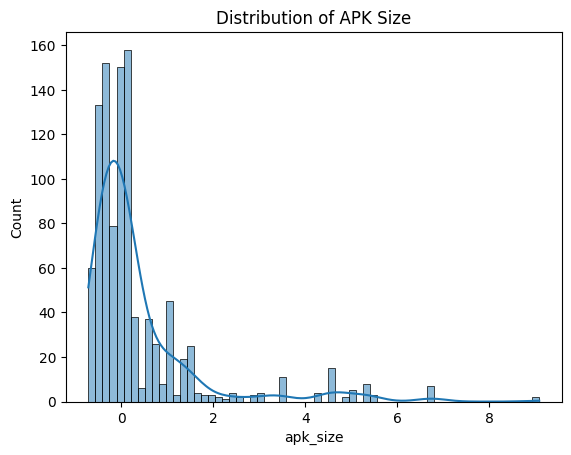

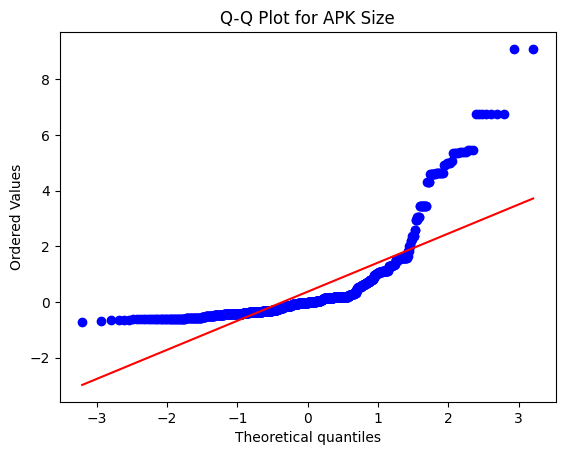

In [21]:
sns.histplot(df["apk_size_scaled"], kde=True)
plt.title("Distribution of APK Size")
plt.xlabel("apk_size")
plt.show()

stats.probplot(df["apk_size_scaled"], dist="norm", plot=plt)
plt.title("Q-Q Plot for APK Size")
plt.show()

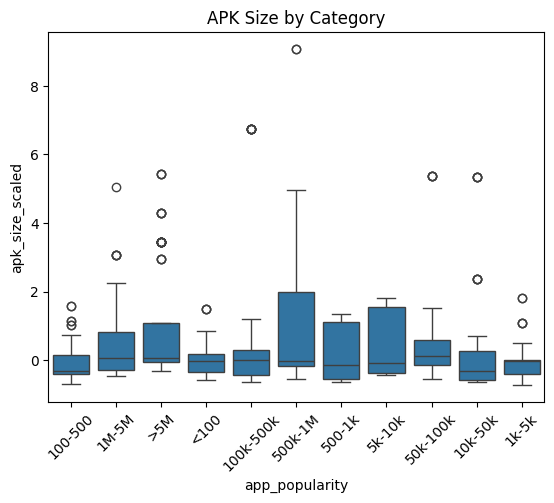

In [22]:
sns.boxplot(x="app_popularity", y="apk_size_scaled", data=df)
plt.xticks(rotation=45)
plt.title("APK Size by Category")
plt.show()

In [23]:
from scipy.stats import kruskal

groups = [g["apk_size_scaled"].values for _, g in df.groupby("app_popularity_encoded", observed=True)]
H_stat, p_value = kruskal(*groups)

print("-----"*10, "Correlation Test for app_popularity -> apk_size", "-----"*10)
print(f"Kruskal–Wallis H = {H_stat:.3f}")
print(f"p-value = {p_value:.5f}")

if p_value < 0.05:
    print("As the p value is less than 0.05, we can say that there is a statistically significant association between the app_popularity and apk_size. It provides evidence to support the hypothesis that the app_popularity influences apk_size. There is correlation in the app_popularity -> apk_size")
else:
    print("\n As the p value is greater than or equal than 0.05, No statistically significant difference detected between APK categories. There is no correlation in the app_popularity -> apk_size direction.")



-------------------------------------------------- Correlation Test for app_popularity -> apk_size --------------------------------------------------
Kruskal–Wallis H = 75.140
p-value = 0.00000
As the p value is less than 0.05, we can say that there is a statistically significant association between the app_popularity and apk_size. It provides evidence to support the hypothesis that the app_popularity influences apk_size. There is correlation in the app_popularity -> apk_size


In [24]:
from scipy.stats import mannwhitneyu, kruskal

def mann_whitney_test(df, numeric_col, binary_col):
    groups = [df[df[binary_col] == val][numeric_col] for val in df[binary_col].unique()]
    stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\n{numeric_col} -> {binary_col}")
    print(f"U = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p


def kruskal_test(df, cat_col, binary_col):
    groups = [group[binary_col].values for _, group in df.groupby(cat_col)]
    stat, p = kruskal(*groups)
    print(f"\n{cat_col} -> {binary_col}")
    print(f"H = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p

def logistic_regression_for_association(df, numeric_col, binary_col):
    X = sm.add_constant(df[numeric_col])
    y = df[binary_col]
    model = sm.Logit(y, X).fit()
    print(f"\nLogistic Regression: {numeric_col} -> {binary_col}")
    # print(model.summary())
    p_value = model.pvalues[numeric_col]
    print(f"\nThe p-value for {numeric_col} is: {round(p_value, 2)}")
    
    if round(p_value, 2) < 0.05:
        print(f"The p-value is less than 0.05. There is a statistically significant impact of {numeric_col} on the {binary_col}.\n\n")
    else:
        print(f"The p-value is 0.05 or greater. There is no statistically significant evidence that {numeric_col} impacts the {binary_col}.\n\n")

    return model

def ordinal_logistic_regression_for_association(df, cat_col, binary_col):
    from statsmodels.miscmodels.ordinal_model import OrderedModel

    X = df[cat_col]
    y = df[binary_col]
    model = OrderedModel(y,X,distr='logit')

    res = model.fit(method='bfgs')
    print(f"\nOrdinal Logistic Regression: {cat_col} -> {binary_col}")
    # print(res.summary())
    p_value = res.pvalues[cat_col]
    print(f"\nThe p-value for {cat_col} is: {round(p_value, 2)}")
    
    if round(p_value, 2)  < 0.05:
        print(f"The p-value is less than 0.05. There is a statistically significant impact of {cat_col} on the {binary_col}.\n\n")
    else:
        print(f"The p-value is 0.05 or greater. There is no statistically significant evidence that {cat_col} impacts the {binary_col}.\n\n")

    return res


print("\n" + "----"*10 + "Statistical Tests for Correlation" + "----"*10)
mann_whitney_test(df, "apk_size_scaled", "verdict")
mann_whitney_test(df, "apk_size_scaled", "is_third_party")
kruskal_test(df, "app_popularity_encoded", "verdict")
kruskal_test(df, "app_popularity_encoded", "is_third_party")


print("\n\n" + "----"*10 + "Logistic Regression for Association" + "----"*10)
logistic_regression_for_association(df, "apk_size_scaled", "verdict")
logistic_regression_for_association(df, "apk_size_scaled", "is_third_party")
ordinal_logistic_regression_for_association(df, "app_popularity_encoded", "verdict")
ordinal_logistic_regression_for_association(df, "app_popularity_encoded", "is_third_party")





----------------------------------------Statistical Tests for Correlation----------------------------------------

apk_size_scaled -> verdict
U = 121200.000, p = 0.1703
No significant difference — weak or no correlation.

apk_size_scaled -> is_third_party
U = 117448.000, p = 0.0054
Significant difference — likely correlation between variables.

app_popularity_encoded -> verdict
H = 44.386, p = 0.0000
Significant difference — likely correlation between variables.

app_popularity_encoded -> is_third_party
H = 74.433, p = 0.0000
Significant difference — likely correlation between variables.


----------------------------------------Logistic Regression for Association----------------------------------------
Optimization terminated successfully.
         Current function value: 0.680328
         Iterations 4

Logistic Regression: apk_size_scaled -> verdict

The p-value for apk_size_scaled is: 0.09
The p-value is 0.05 or greater. There is no statistically significant evidence that apk_size_

So, as there is no correlation in __apk_size_scaled -> verdict__, below is our final causal graph: \
*digraph {\
    is_third_party -> verdict;\
    apk_size_scaled -> is_third_party;\
    app_popularity_encoded -> is_third_party;\
    app_popularity_encoded -> verdict;\
    app_popularity_encoded -> apk_size_scaled;\
}*